<a href="https://colab.research.google.com/github/merryjman/Neutrino-Camp/blob/main/dampedOscillatorGradDescent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2>Data Analysis Practice:</h2>
<h3>Damped Oscillator</h3><br>

Here, we are going to explore various ways to test the power of various fitting methods. For our context we will use the classic damped oscillator equation<br> <font size = 10>$$ x(t) = A e^{-\gamma t} \cos(\omega t) $$</font><br> where:

A=amplitude<br>&gamma; = damping coefficient<br>&omega; = angular frequency<br><i>(We'll ignore phase for now)</i><br>
<br>

The code will simulate a noisy set of underdamped oscillator data, then plot those data. Feel free to alter aspects of the plot to get a feel for what the code is doing.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Time array
num_points=1000
t = np.linspace(0, 10, num_points)

#Set the three oscillation parameter values, plus the "noisiness" level in the data
#An optional extension would be to lay out the parameters underlying omega, for different damping scenarios.
sim_A, sim_gamma, sim_omega, noise_level = 1.5, 0.3, 2.5, 0.15

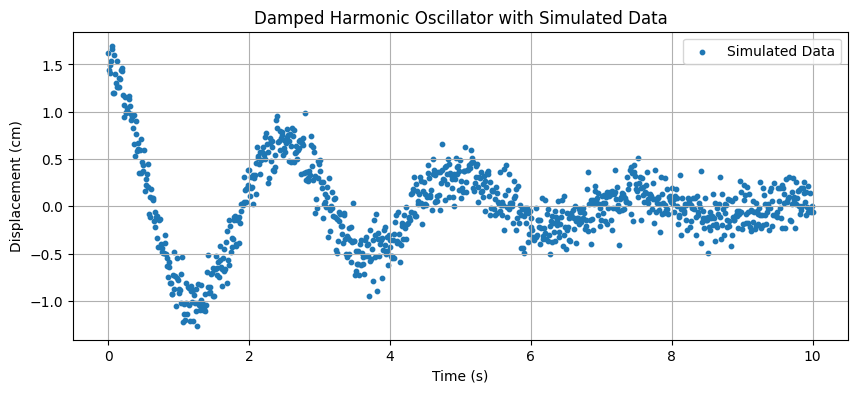

In [ ]:
# the oscillator curve
def damped_oscillator(t, A, gamma, omega):
    return A * np.exp(-gamma * t) * np.cos(omega * t)

# the data to be plotted. you can make it more or less noisy later.
def generate_noisy_data(t, A, gamma, omega, noise_level):
    """Generates synthetic data for a damped oscillator with added noise."""
    theoretical_y = damped_oscillator(t, A, gamma, omega)
    noise = np.random.normal(0, noise_level, theoretical_y.shape)
    noisy_y = theoretical_y + noise
    return noisy_y


# if you want the plot to generate new noisy data each time you change the slider,
# put this line inside the plot_damped_oscillator function below.
noisy_y = generate_noisy_data(t, sim_A, sim_gamma, sim_omega, noise_level)


#just as a sanity check, you can uncomment the line below to see the dataset.
#noisy_y


plt.figure(figsize=(10, 4))
    # Plot simulated data as scatter points
plt.scatter(t, noisy_y, label="Simulated Data", s=10) # s is marker size


plt.title(f"Damped Harmonic Oscillator with Simulated Data")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (cm)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# initialize ML parameters

A = 1.0
gamma = 1.0
omega = 1.0

learning_rate = 0.1
epochs = 325

loss_history = []

In [ ]:
# Gradient descent to train the model

for i in range(epochs):
  y_pred = A * np.exp(-gamma*t)*np.cos(omega*t)
  error = noisy_y - y_pred
  loss = np.mean(error**2)
  loss_history.append(loss)

  # Compute the gradients
  dA = -2 * np.mean(error * np.exp(-gamma * t) * np.cos(omega * t))
  dgamma = -2 * np.mean(error * A * (-t) * np.exp(-gamma*t) * np.cos(omega * t))
  domega = -2 * np.mean(error * (-A)*t*np.exp(-gamma*t)*np.sin(omega*t))

  # Update parameters
  A = A - learning_rate * dA
  gamma = gamma - learning_rate * dgamma
  omega = omega - learning_rate * domega

# Output the results
print("Learned A (Amplitude)", A , " Ideal A ", sim_A)
print("Learned Gamma (damping)", gamma, " Ideal gamma ", sim_gamma)
print("Learned Omega (frequency)", omega, " Ideal omega ", sim_omega)


Learned A (Amplitude) 1.63431684378907  Ideal A  1.5
Learned Gamma (damping) 0.33686125501280273  Ideal gamma  0.3
Learned Omega (frequency) 2.4962906712428268  Ideal omega  2.5


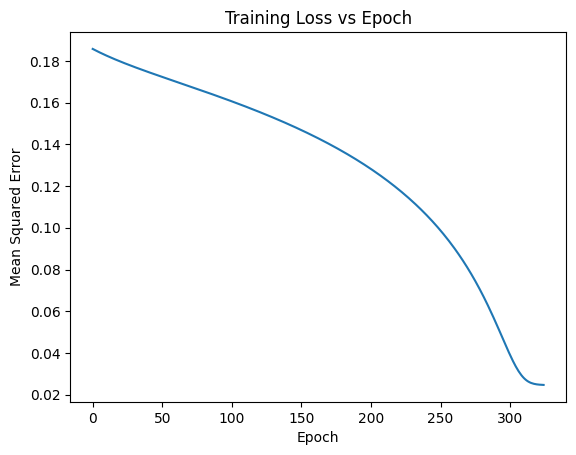

In [ ]:
# Loss vs Epoch
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Training Loss vs Epoch")
plt.show()

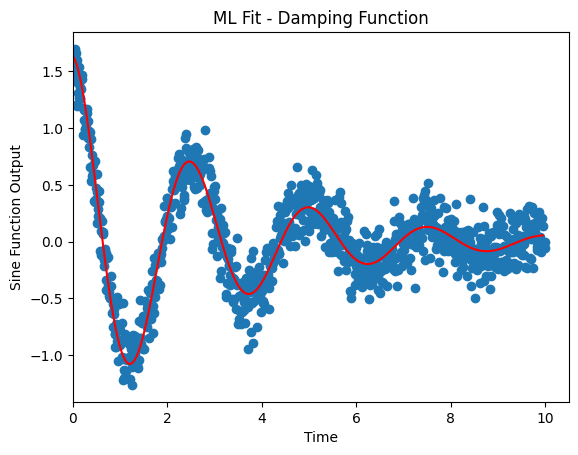

In [ ]:
# Do a Plot to visually see how things went...

# Creating a scatter plot graph
xMin = 0
xMax = np.max(t)

plt.scatter(x = t, y = noisy_y)
xValues = np.arange(xMin, xMax, (xMax - xMin)/200)
plt.plot(xValues, A * np.exp(-gamma*xValues)*np.cos(omega*xValues), color = "r")
plt.axis(xmin = xMin)
plt.title("ML Fit - Damping Function")
plt.xlabel("Time")
plt.ylabel("Sine Function Output")
plt.show()